# Test Cuantización - Fingers Dataset

## PARTE 1: PREPARACIÓN 
Este notebook se divide en dos partes principales:

1. **PARTE DE PREPARACION**: Extrae features, entrena modelos base, genera datos cuantizados, y guarda todos los artefactos (modelos, CSV, escalares normalizador).

2. **PARTE DE EVALUACION**: Carga los artefactos preparados y realiza evaluación, comparación de errores, y análisis. Se puede modificar y ejecutar múltiples veces sin recalcular nada.

Área: 3740.0
Perímetro: 343.49747468305833
Excentricidad: 0.05970895058121077
Solidez: 0.9130859375
Bounding box: (0, 0, 64, 64)
Centroide: (np.float64(31.470320855614972), np.float64(31.55133689839572))
----------------------------------------
Área: 34.0
Perímetro: 23.485281374238568
Excentricidad: 0.9413057228483238
Solidez: 0.723404255319149
Bounding box: (30, 26, 36, 38)
Centroide: (np.float64(32.529411764705884), np.float64(31.058823529411764))
----------------------------------------


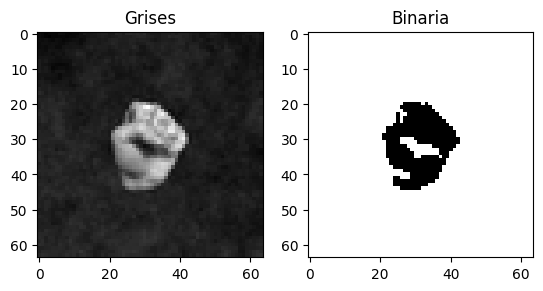

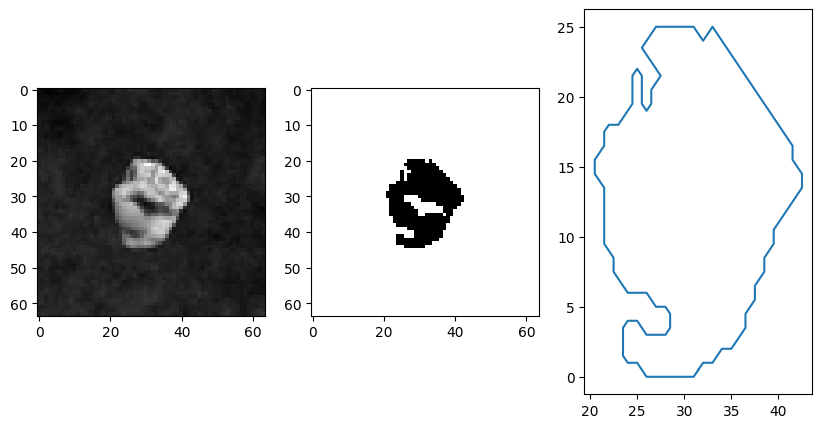

In [22]:
## Visualización Inicial (Referencia)

# Mostrar características extraíbles de una imagen del dataset
FUENTES_DIR = '../Fuentes'         # carpeta donde se encuentran archivos .py auxiliares
DATOS_DIR   = '../Imagenes/Fingers/' # carpeta donde se encuentran los datasets
import os, glob, math, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.filters import threshold_otsu
from skimage.morphology import closing, footprint_rectangle
from skimage.segmentation import clear_border
from skimage.measure import regionprops, label, find_contours

img = io.imread(DATOS_DIR + "samples/0L.png")
# Si la imagen tiene 4 canales (RGBA), convertir a RGB antes de pasar a escala de grises
if img.shape[-1] == 4:
    img_rgb = img[..., :3]
    gray = color.rgb2gray(img_rgb)
else:
    gray = color.rgb2gray(img) if len(img.shape) == 3 else img

# binarización (umbral automático Otsu)
thresh = threshold_otsu(gray)
binary = gray < thresh  # mano en blanco (1), fondo negro (0)

# etiquetar regiones
label_img = label(binary)

# extraer propiedades
props = regionprops(label_img)

# mostrar algunas propiedades de la primera región
for prop in props:
    print(f"Área: {prop.area}")
    print(f"Perímetro: {prop.perimeter}")
    print(f"Excentricidad: {prop.eccentricity}")
    print(f"Solidez: {prop.solidity}")
    print(f"Bounding box: {prop.bbox}")
    print(f"Centroide: {prop.centroid}")
    print("-" * 40)

# graficar
plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Grises")

plt.subplot(1,2,2)
plt.imshow(binary, cmap="gray")
plt.title("Binaria")
plt.show()

fig, axs = plt.subplots(1,3, figsize=(10,5))
axs[0].imshow(gray, cmap='gray')
axs[1].imshow(binary, cmap='gray')

contour = find_contours(binary, 0.5)[0]
y, x = contour.T

axs[2].plot(x, y.max()-y)

---
## INICIO: PARTE 1 - PREPARACION
---

Ejecuta esta sección una sola vez. Genera todos los artefactos necesarios (modelos, datos, escalares) que serán usados en la PARTE 2 (Evaluacion).

**Outputs generados:**
- Modelos: `fingers_model_no_quantization.h5`, `fingers_model_q_signed_symmetric_per_layer.h5`, `fingers_model_q_signed_symmetric_per_neuron.h5` (+ TFLite)
- Datos: CSVs cuantizados y no-cuantizados
- Escalares: `normalizer.pkl`

---
# PARTE 1: PREPARACION
---

## 1. Extraccion de caracteristicas desde imagenes

Convierte las imágenes en las carpetas **"test"** y **"train"** del dataset **"Fingers"** en dos archivos (uno por carpeta) separados por comas (csv). De todas las características que provee **regionprops**, tienen potencial aquellas que son independientes o se pueden independizar de las unidades (píxeles). Algunas de estas características pueden ser:

- **filled_area:** cantidad de píxeles que contiene región (podría interpretarse como píxeles cuadrados).
- **major_axis_length:** longitud (en píxeles) del eje mayor de la elipse que mejor se ajusta a la región.
- **minor_axis_length:** longitud (en píxeles) del eje menor de la elipse que mejor se ajusta a la región.
- **perimeter:** cantidad de píxeles que forman el contorne de la región.
- **eccentricity:** excentricidad de la elipse de mejor ajuste, cerca de 0 es un círculo, mientras que cerca de 1 es una elipse más "larga".
- **solidity:** razón entre la cantidad de píxeles de la región original y de la región convexa. Para generar una región convexa se completan los pixeles de forma de eliminar regiones cóncavas de una figura. La región convexa de una estrella de 5 puntas se convertirá en un pentágono al completarla.
- **extent:** razón entre pixeles de la región original y el rectángulo que la contiene (bounding box).

In [ ]:
import os, warnings, sys
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore", category=FutureWarning)  # silencia warnings 

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utility.convertir_dataset import convertir_dataset

# Estructura organizada de datasets
DATASETS_ROOT = "../Data_Sets"
DATASETS_RAW_DIR = os.path.join(DATASETS_ROOT, "raw")
os.makedirs(DATASETS_RAW_DIR, exist_ok=True)

convertir_dataset("../Imagenes/Fingers/train", os.path.join(DATASETS_RAW_DIR, "fingers_train.csv"))
convertir_dataset("../Imagenes/Fingers/test",  os.path.join(DATASETS_RAW_DIR, "fingers_test.csv"))

Procesando 17999/17999 imágenes (100.00%)
✅ Guardado en ../Data_Sets/fingers_train.csv
Procesando 3600/3600 imágenes (100.00%)
✅ Guardado en ../Data_Sets/fingers_test.csv


## 2. Carga de datos, normalizacion y entrenamiento del modelo base

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib  # para guardar el normalizer
import pickle

from sklearn import preprocessing, metrics, model_selection

from sklearn.model_selection import cross_val_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
import seaborn as sns

DATASETS_ROOT = '../Data_Sets'
DATASETS_RAW_DIR = os.path.join(DATASETS_ROOT, 'raw')
DATASETS_METADATA_DIR = os.path.join(DATASETS_ROOT, 'metadata')
os.makedirs(DATASETS_METADATA_DIR, exist_ok=True)

# CARGA DE DATASET
nom_archivo = os.path.join(DATASETS_RAW_DIR, 'fingers_train.csv')
datos = pd.read_csv(nom_archivo)

# separa características y clase
X = np.array(datos.iloc[:, :-1])
Y = np.array(datos.iloc[:, -1])
nomClases = datos.iloc[:, -1].value_counts()

# Target codificado como one-hot
encoder = preprocessing.LabelEncoder()
Y_nro = encoder.fit_transform(Y)
Y_bin= to_categorical(Y_nro)

# CONJUNTOS DE ENTRENAMIENTO Y VALIDACION
X_train, X_val, Y_train, Y_val = model_selection.train_test_split( \
                                         X, Y_bin, test_size=0.20, random_state=42)

normalizador = preprocessing.StandardScaler()
X_train = normalizador.fit_transform(X_train)
X_val = normalizador.transform(X_val)

# Guardar normalizer para uso en evaluación
normalizer_path = os.path.join(DATASETS_METADATA_DIR, 'normalizer.pkl')
joblib.dump(normalizador, normalizer_path)
print(f"✅ Normalizer guardado en {normalizer_path}")

datos

✅ Normalizer guardado en ../Data_Sets/normalizer.pkl


,AreaNorm,PerimNorm,RazonEjes,Excentricidad,Solidez,Extension,CantDedos
0,0.772097,3.455084,0.679345,0.733819,0.932500,0.690741,0
1,0.747383,3.474195,0.642108,0.766614,0.922849,0.691111,0
2,0.734556,4.203402,0.766965,0.641689,0.892857,0.636364,0
3,0.768645,3.446018,0.730245,0.683185,0.925414,0.670000,0
4,0.774000,3.365307,0.730927,0.682455,0.940510,0.728070,0
...,...,...,...,...,...,...,...
17994,0.551767,5.648539,0.633040,0.774119,0.576408,0.393773,5
17995,0.576778,5.770199,0.699539,0.714595,0.600000,0.371512,5
17996,0.538463,6.011802,0.712541,0.701631,0.555088,0.365854,5
17997,0.605275,5.455247,0.732710,0.680541,0.613725,0.382173,5


### 3a. Arquitectura y entrenamiento del modelo base

In [ ]:
ENTRADAS = X_train.shape[1]
SALIDAS = Y_train.shape[1]
OCULTAS = 8
EPOCAS = 200
LOTES = 32
PACIENCIA = 5
ACTIVACION = 'tanh'
OPTIMIZADOR = 'adam'

# %% CONSTRUCCION DEL MODELO
model = Sequential()
model.add(Dense(OCULTAS, input_shape=[ENTRADAS], activation=ACTIVACION))
model.add(Dense(SALIDAS, activation='softmax'))
model.summary()  #-- muestra la cantidad de parámetros de la red

model.compile(optimizer=OPTIMIZADOR, loss='categorical_crossentropy', metrics=['accuracy'])

# %% ENTRENAMIENTO

# parada temprana para evitar el sobreajuste
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=PACIENCIA)

# entrena el modelo y guarda la historia del progreso
history = model.fit(X_train,Y_train, epochs=EPOCAS, batch_size=LOTES, validation_data = (X_val, Y_val), callbacks=[early_stop])

# Guarda el modelo entrenado en estructura organizada
MODELS_ROOT = '../Models'
MODELS_BASE_DIR = os.path.join(MODELS_ROOT, 'base')
os.makedirs(MODELS_BASE_DIR, exist_ok=True)
model.save(os.path.join(MODELS_BASE_DIR, 'fingers_model_no_quantization.h5'))

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │            54 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110 (440.00 B)

 Trainable params: 110 (440.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6266 - loss: 1.1469 - val_accuracy: 0.7747 - val_loss: 0.7575
Epoch 2/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 834us/step - accuracy: 0.8320 - loss: 0.6029 - val_accuracy: 0.8664 - val_loss: 0.4977
Epoch 3/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step - accuracy: 0.9110 - loss: 0.4296 - val_accuracy: 0.9328 - val_loss: 0.3735
Epoch 4/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step - accuracy: 0.9391 - loss: 0.3318 - val_accuracy: 0.9428 - val_loss: 0.2947
Epoch 5/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - accuracy: 0.9462 - loss: 0.2666 - val_accuracy: 0.9506 - val_loss: 0.2403
Epoch 6/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step - accuracy: 0.9531 - loss: 0.2220 - val_accuracy: 0.9556 - val_loss: 0.2009
Epoch 7/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step - accuracy: 0.9577 - loss: 0.1896 - val_accuracy: 0.9581 - val_loss: 0.1718
Epoch 8/200
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - accuracy: 0.9610 - loss: 0.1

## 3b. Cuantizacion y procesamiento de pesos/datos de E/S

Cuantización simétrica con signo: se cuantizan los pesos del modelo usando int8 (dos versiones: por capa, y por neurona). Se cuantizan también las entradas y salidas de los modelos, generando múltiples flujos (E/S de-cuantizada vs E/S cuantizada). Se guardan todos los modelos y datos para la fase de evaluación.

In [ ]:
import os
import sys
import warnings
import logging

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import tensorflow as tf
from absl import logging as absl_logging

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utility.quantize_symmetric_signed import quantize_symmetric_signed
from utility.quantize_dense_weights_symmetric import quantize_dense_weights_symmetric
from utility.export_full_int8_tflite import export_full_int8_tflite
from utility.quantize_csv_inputs_with_scale import quantize_csv_inputs_with_scale

tf.get_logger().setLevel('ERROR')
logging.getLogger('tensorflow').setLevel(logging.ERROR)
absl_logging.set_verbosity(absl_logging.ERROR)

# Estructura organizada
DATASETS_ROOT = '../Data_Sets'
DATASETS_RAW_DIR = os.path.join(DATASETS_ROOT, 'raw')
DATASETS_QUANTIZED_DIR = os.path.join(DATASETS_ROOT, 'quantized')
DATASETS_METADATA_DIR = os.path.join(DATASETS_ROOT, 'metadata')
DATASETS_REPORTS_DIR = os.path.join(DATASETS_ROOT, 'reports')

MODELS_ROOT = '../Models'
MODELS_BASE_DIR = os.path.join(MODELS_ROOT, 'base')
MODELS_QUANTIZED_H5_DIR = os.path.join(MODELS_ROOT, 'quantized_h5')
MODELS_QUANTIZED_TFLITE_DIR = os.path.join(MODELS_ROOT, 'quantized_tflite')

for p in [
    DATASETS_RAW_DIR, DATASETS_QUANTIZED_DIR, DATASETS_METADATA_DIR, DATASETS_REPORTS_DIR,
    MODELS_BASE_DIR, MODELS_QUANTIZED_H5_DIR, MODELS_QUANTIZED_TFLITE_DIR,
    os.path.join(MODELS_ROOT, 'repaired_h5'), os.path.join(MODELS_ROOT, 'repaired_tflite')
]:
    os.makedirs(p, exist_ok=True)

BASE_MODEL_PATH = os.path.join(MODELS_BASE_DIR, 'fingers_model_no_quantization.h5')
BITS_W = 8
BITS_IO = 8

print('=' * 70)
print('CONSTRUCCIÓN DE MODELOS CUANTIZADOS')
print('=' * 70)

base_model = tf.keras.models.load_model(BASE_MODEL_PATH)
print('✅ Modelo base cargado\n')

# Cuantización de pesos por capa
print('Cuantizando pesos por capa...')
model_q_layer = quantize_dense_weights_symmetric(base_model, bits=BITS_W, mode='per_layer')
print('✅ Modelo per-layer completado\n')

# Cuantización de pesos por neurona
print('Cuantizando pesos por neurona...')
model_q_neuron = quantize_dense_weights_symmetric(base_model, bits=BITS_W, mode='per_neuron')
print('✅ Modelo per-neuron completado\n')

# Guardar modelos cuantizados en formato Keras H5
print('Guardando modelos H5 para carga rápida en evaluación...')
model_q_layer.save(os.path.join(MODELS_QUANTIZED_H5_DIR, 'fingers_model_q_signed_symmetric_per_layer.h5'))
model_q_neuron.save(os.path.join(MODELS_QUANTIZED_H5_DIR, 'fingers_model_q_signed_symmetric_per_neuron.h5'))
print('✅ Modelos H5 guardados en quantized_h5/')

# Guardar modelos int8 reales en TFLite
print('Exportando modelos int8 a TFLite...')
export_full_int8_tflite(
    model_q_layer,
    os.path.join(MODELS_QUANTIZED_TFLITE_DIR, 'fingers_model_q_signed_symmetric_per_layer_int8.tflite'),
    X_train,
 )
export_full_int8_tflite(
    model_q_neuron,
    os.path.join(MODELS_QUANTIZED_TFLITE_DIR, 'fingers_model_q_signed_symmetric_per_neuron_int8.tflite'),
    X_train,
 )
print('✅ Modelos TFLite guardados en quantized_tflite/\n')

# Cuantizar datasets normalizados y guardar metadata exacta de escalas
print('Generando CSVs cuantizados normalizados + metadata exacta de cuantización...')
train_src = os.path.join(DATASETS_RAW_DIR, 'fingers_train.csv')
train_dst = os.path.join(DATASETS_QUANTIZED_DIR, 'fingers_train_quant8_signed_symmetric.csv')
test_src = os.path.join(DATASETS_RAW_DIR, 'fingers_test.csv')
test_dst = os.path.join(DATASETS_QUANTIZED_DIR, 'fingers_test_quant8_signed_symmetric.csv')

train_scale, feature_columns = quantize_csv_inputs_with_scale(train_src, train_dst, normalizador, bits=BITS_IO)
test_scale, _ = quantize_csv_inputs_with_scale(test_src, test_dst, normalizador, bits=BITS_IO)

meta_out = os.path.join(DATASETS_METADATA_DIR, 'quantization_metadata_signed_symmetric.npz')
np.savez(
    meta_out,
    bits_io=np.array([BITS_IO], dtype=np.int32),
    qmax=np.array([(2 ** (BITS_IO - 1)) - 1], dtype=np.int32),
    train_scale=train_scale,
    test_scale=test_scale,
    feature_columns=np.array(feature_columns, dtype=object),
    inputs_are_normalized=np.array([1], dtype=np.int32),
)
print('✅ CSVs cuantizados y metadata guardados en estructura organizada\n')

print('=' * 70)
print('✅ PARTE 1: PREPARACIÓN COMPLETADA')
print('=' * 70)
print('\nTodos los artefactos han sido guardados.')
print('Ahora puedes ejecutar PARTE 2: EVALUACIÓN\n')
print('=' * 70)

CONSTRUCCIÓN DE MODELOS CUANTIZADOS
✅ Modelo base cargado

Cuantizando pesos por capa...
✅ Modelo per-layer completado

Cuantizando pesos por neurona...
✅ Modelo per-neuron completado

Guardando modelos H5 para carga rápida en evaluación...
✅ Modelos H5 guardados:
  - fingers_model_q_signed_symmetric_per_layer.h5
  - fingers_model_q_signed_symmetric_per_neuron.h5

Exportando modelos int8 a TFLite...
✅ Modelos TFLite guardados:
  - fingers_model_q_signed_symmetric_per_layer_int8.tflite
  - fingers_model_q_signed_symmetric_per_neuron_int8.tflite

Generando CSVs cuantizados normalizados + metadata exacta de cuantización...
✅ CSVs cuantizados y metadata guardados:
  - fingers_train_quant8_signed_symmetric.csv
  - fingers_test_quant8_signed_symmetric.csv
  - quantization_metadata_signed_symmetric.npz

✅ PARTE 1: PREPARACIÓN COMPLETADA

Todos los artefactos han sido guardados.
Ahora puedes ejecutar PARTE 2: EVALUACIÓN



### 3c. Exportación de artefactos para implementación en C (MCU)

In [ ]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utility.export_c_assets import export_c_assets

C_MODEL_DATA_DIR = export_c_assets(project_root=PROJECT_ROOT)
print('✅ Exportación para C completada en:', C_MODEL_DATA_DIR)
print('   - CSVs de pesos cuantizados (per-layer y per-neuron)')
print('   - CSVs de entradas cuantizadas (copiados)')
print('   - quantization_metadata_c.json (incluye escalas de inputs y pesos)')

## 3.d Analisis de valores atipicos en pesos y datos

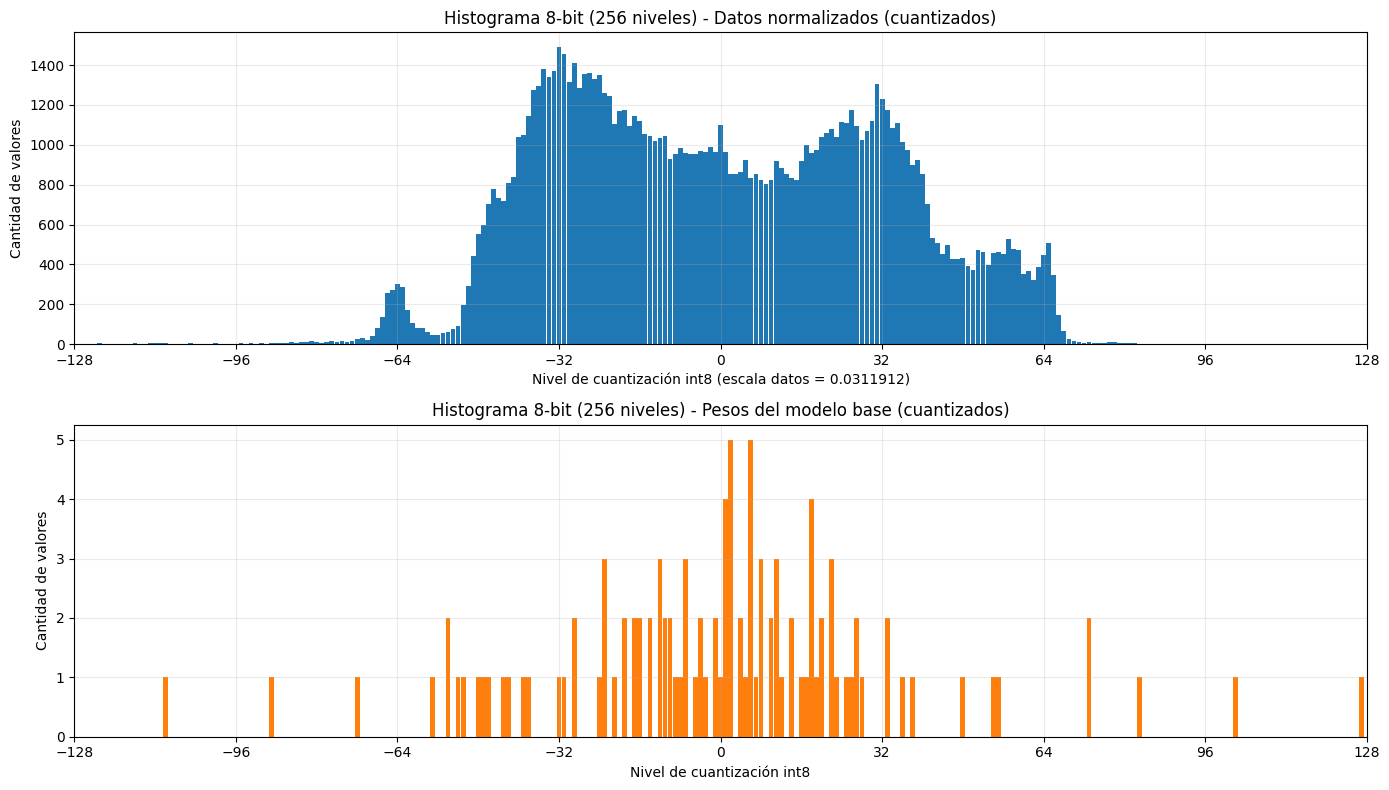

Niveles usados (datos): 207 / 256
Niveles usados (pesos): 67 / 256
Valores en saturación (datos): 1
Valores en saturación (pesos): 1

Imágenes guardadas en:
 - ../Imagenes/histogramas/histograma_datos_y_pesos_int8.png
 - ../Imagenes/histogramas/histograma_datos_int8.png
 - ../Imagenes/histogramas/histograma_pesos_int8.png


In [ ]:
# Verificacion de valores atipicos: histogramas de niveles de cuantizacion (256 niveles)
import os
import sys
import warnings
import logging
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# Reducir al mínimo los warnings/logs de TensorFlow para esta celda
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
warnings.filterwarnings('ignore')

import tensorflow as tf
from absl import logging as absl_logging

tf.get_logger().setLevel('ERROR')
logging.getLogger('tensorflow').setLevel(logging.ERROR)
absl_logging.set_verbosity(absl_logging.ERROR)
try:
    tf.config.set_visible_devices([], 'GPU')
except Exception:
    pass

# Reusar la funcion de cuantizacion existente
if 'quantize_symmetric_signed' in globals():
    quantize_fn = quantize_symmetric_signed
else:
    fuentes_dir = os.path.abspath('../Fuentes')
    if fuentes_dir not in sys.path:
        sys.path.insert(0, fuentes_dir)
    from quantize_signed_symmetric_inputs import quantize_symmetric_signed as quantize_fn

DATASETS_ROOT = '../Data_Sets'
DATASETS_RAW_DIR = os.path.join(DATASETS_ROOT, 'raw')
DATASETS_METADATA_DIR = os.path.join(DATASETS_ROOT, 'metadata')
MODELS_ROOT = '../Models'
MODELS_BASE_DIR = os.path.join(MODELS_ROOT, 'base')

base_model_hist = tf.keras.models.load_model(os.path.join(MODELS_BASE_DIR, 'fingers_model_no_quantization.h5'))

# 1) Datos normalizados (como en entrenamiento) -> mapear a niveles int8
raw_train_df = pd.read_csv(os.path.join(DATASETS_RAW_DIR, 'fingers_train.csv'))
normalizador = joblib.load(os.path.join(DATASETS_METADATA_DIR, 'normalizer.pkl'))
raw_x = raw_train_df.iloc[:, :-1].to_numpy(dtype=np.float32)
x_norm = normalizador.transform(raw_x).reshape(-1)
q_data, _, scale_data = quantize_fn(x_norm, bits=8, axis=None)
q_data = q_data.reshape(-1)
scale_data = float(np.asarray(scale_data).reshape(-1)[0])

# 2) Pesos del modelo base -> mapear a niveles int8
weights_flat = np.concatenate([w.astype(np.float32).reshape(-1) for w in base_model_hist.get_weights()])
q_w, _, _ = quantize_fn(weights_flat, bits=8, axis=None)
q_w = q_w.reshape(-1)

# Histograma de 256 niveles: [-128, 127]
level_edges = np.arange(-128.5, 128.5, 1.0)
level_centers = np.arange(-128, 128, 1)

hist_data, _ = np.histogram(q_data, bins=level_edges)
hist_w, _ = np.histogram(q_w, bins=level_edges)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(level_centers, hist_data, width=0.95)
axes[0].set_title('Histograma 8-bit (256 niveles) - Datos normalizados (cuantizados)')
axes[0].set_xlabel(f'Nivel de cuantización int8 (escala datos = {scale_data:.6g})')
axes[0].set_ylabel('Cantidad de valores')
axes[0].grid(alpha=0.25)

axes[1].bar(level_centers, hist_w, width=0.95, color='tab:orange')
axes[1].set_title('Histograma 8-bit (256 niveles) - Pesos del modelo base (cuantizados)')
axes[1].set_xlabel('Nivel de cuantización int8')
axes[1].set_ylabel('Cantidad de valores')
axes[1].grid(alpha=0.25)

# Mostrar números del eje x también en el histograma superior
xticks_int8 = np.arange(-128, 129, 32)
for ax in axes:
    ax.set_xlim(-128, 127)
    ax.set_xticks(xticks_int8)
axes[0].tick_params(axis='x', labelbottom=True)

plt.tight_layout()

# Guardar imágenes de histogramas
hist_dir = '../Imagenes/histogramas'
os.makedirs(hist_dir, exist_ok=True)

path_comb = os.path.join(hist_dir, 'histograma_datos_y_pesos_int8.png')
fig.savefig(path_comb, dpi=200, bbox_inches='tight')

fig_data, ax_data = plt.subplots(figsize=(14, 4.5))
ax_data.bar(level_centers, hist_data, width=0.95)
ax_data.set_title('Histograma 8-bit (256 niveles) - Datos normalizados (cuantizados)')
ax_data.set_xlabel(f'Nivel de cuantización int8 (escala datos = {scale_data:.6g})')
ax_data.set_ylabel('Cantidad de valores')
ax_data.set_xlim(-128, 127)
ax_data.set_xticks(xticks_int8)
ax_data.grid(alpha=0.25)
fig_data.tight_layout()
path_data = os.path.join(hist_dir, 'histograma_datos_int8.png')
fig_data.savefig(path_data, dpi=200, bbox_inches='tight')
plt.close(fig_data)

fig_w, ax_w = plt.subplots(figsize=(14, 4.5))
ax_w.bar(level_centers, hist_w, width=0.95, color='tab:orange')
ax_w.set_title('Histograma 8-bit (256 niveles) - Pesos del modelo base (cuantizados)')
ax_w.set_xlabel('Nivel de cuantización int8')
ax_w.set_ylabel('Cantidad de valores')
ax_w.set_xlim(-128, 127)
ax_w.set_xticks(xticks_int8)
ax_w.grid(alpha=0.25)
fig_w.tight_layout()
path_w = os.path.join(hist_dir, 'histograma_pesos_int8.png')
fig_w.savefig(path_w, dpi=200, bbox_inches='tight')
plt.close(fig_w)

plt.show()

qmax_int8 = 127
sat_data = int(np.sum(np.abs(q_data) == qmax_int8))
sat_w = int(np.sum(np.abs(q_w) == qmax_int8))

print('Niveles usados (datos):', int(np.count_nonzero(hist_data)), '/ 256')
print('Niveles usados (pesos):', int(np.count_nonzero(hist_w)), '/ 256')
print('Valores en saturación (datos):', sat_data)
print('Valores en saturación (pesos):', sat_w)
print('\nImágenes guardadas en:')
print(' -', path_comb)
print(' -', path_data)
print(' -', path_w)

---
# PARTE 2: EVALUACION
---
## Cargar artefactos precomputados

Carga todos los modelos, datos y artefactos generados en la parte de preparación. 

In [13]:
import os
import sys
import numpy as np
import pandas as pd
import joblib
import warnings
import logging

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import tensorflow as tf
from sklearn import metrics
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from utility.dequantize_saved_inputs import dequantize_saved_inputs
from utility.evaluate_baseline import evaluate_baseline
from utility.evaluate_pipeline_io_quantized_from_csv import evaluate_pipeline_io_quantized_from_csv
from utility.evaluate_pipeline_io_dequantized_from_csv import evaluate_pipeline_io_dequantized_from_csv

# Silenciar logs
tf.get_logger().setLevel('ERROR')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# Estructura organizada
DATASETS_ROOT = '../Data_Sets'
DATASETS_RAW_DIR = os.path.join(DATASETS_ROOT, 'raw')
DATASETS_QUANTIZED_DIR = os.path.join(DATASETS_ROOT, 'quantized')
DATASETS_METADATA_DIR = os.path.join(DATASETS_ROOT, 'metadata')
DATASETS_REPORTS_DIR = os.path.join(DATASETS_ROOT, 'reports')

MODELS_ROOT = '../Models'
MODELS_BASE_DIR = os.path.join(MODELS_ROOT, 'base')
MODELS_QUANTIZED_H5_DIR = os.path.join(MODELS_ROOT, 'quantized_h5')
MODELS_QUANTIZED_TFLITE_DIR = os.path.join(MODELS_ROOT, 'quantized_tflite')
MODELS_REPAIRED_H5_DIR = os.path.join(MODELS_ROOT, 'repaired_h5')
MODELS_REPAIRED_TFLITE_DIR = os.path.join(MODELS_ROOT, 'repaired_tflite')

for p in [
    DATASETS_RAW_DIR, DATASETS_QUANTIZED_DIR, DATASETS_METADATA_DIR, DATASETS_REPORTS_DIR,
    MODELS_BASE_DIR, MODELS_QUANTIZED_H5_DIR, MODELS_QUANTIZED_TFLITE_DIR, MODELS_REPAIRED_H5_DIR, MODELS_REPAIRED_TFLITE_DIR,
]:
    os.makedirs(p, exist_ok=True)

# Compatibilidad con celdas existentes que usan estas variables
DATOS_DIR = DATASETS_REPORTS_DIR + '/'
MODELOS_DIR = MODELS_REPAIRED_H5_DIR + '/'

# Cargar normalizador
normalizador = joblib.load(os.path.join(DATASETS_METADATA_DIR, 'normalizer.pkl'))

# Cargar modelos
base_model = tf.keras.models.load_model(os.path.join(MODELS_BASE_DIR, 'fingers_model_no_quantization.h5'))

try:
    model_q_layer = tf.keras.models.load_model(os.path.join(MODELS_QUANTIZED_H5_DIR, 'fingers_model_q_signed_symmetric_per_layer.h5'))
    model_q_neuron = tf.keras.models.load_model(os.path.join(MODELS_QUANTIZED_H5_DIR, 'fingers_model_q_signed_symmetric_per_neuron.h5'))
    print('✅ Modelos cuantizados (H5) cargados')
    quantized_models_available = True
except FileNotFoundError:
    print('⚠️  Modelos H5 cuantizados no encontrados.')
    quantized_models_available = False

# Cargar metadatos exactos de cuantizacion desde Preparacion
meta_path = os.path.join(DATASETS_METADATA_DIR, 'quantization_metadata_signed_symmetric.npz')
if os.path.exists(meta_path):
    qmeta = np.load(meta_path, allow_pickle=True)
    train_input_scale_exact = qmeta['train_scale'].astype(np.float32)
    test_input_scale_exact = qmeta['test_scale'].astype(np.float32)
    bits_io_exact = int(qmeta['bits_io'][0])
    print('✅ Metadata de cuantización exacta cargada')
else:
    train_input_scale_exact = None
    test_input_scale_exact = None
    bits_io_exact = 8
    print('⚠️  Metadata de cuantización no encontrada (ejecuta PART 1).')

num_classes = int(base_model.output_shape[-1])

# Cargar dataset en coma flotante (para modelo base)
datos_float = pd.read_csv(os.path.join(DATASETS_RAW_DIR, 'fingers_train.csv'))
X_float = np.array(datos_float.iloc[:, :-1], dtype=np.float32)
Y_float_raw = np.array(datos_float.iloc[:, -1]).astype(np.int32)
Y_float_bin = to_categorical(Y_float_raw, num_classes=num_classes)

X_train_float, X_val_float, Y_train_float, Y_val_float = train_test_split(
    X_float, Y_float_bin, test_size=0.20, random_state=42
)
# Reusa el normalizador entrenado en preparación (sin refit)
X_train_float = normalizador.transform(X_train_float)
X_val_float = normalizador.transform(X_val_float)

# Cargar datasets pre-cuantizados (sin recalculo)
datos_q_train = pd.read_csv(os.path.join(DATASETS_QUANTIZED_DIR, 'fingers_train_quant8_signed_symmetric.csv'))
datos_q_test = pd.read_csv(os.path.join(DATASETS_QUANTIZED_DIR, 'fingers_test_quant8_signed_symmetric.csv'))

X_train_q = np.array(datos_q_train.iloc[:, :-1], dtype=np.float32)
Y_train_q_raw = np.array(datos_q_train.iloc[:, -1]).astype(np.int32)
X_test_q = np.array(datos_q_test.iloc[:, :-1], dtype=np.float32)
Y_test_q_raw = np.array(datos_q_test.iloc[:, -1]).astype(np.int32)

# Sin re-encoding: las etiquetas ya están como clases enteras
Y_train_q = to_categorical(Y_train_q_raw, num_classes=num_classes)
Y_test_q = to_categorical(Y_test_q_raw, num_classes=num_classes)

BITS_IO = bits_io_exact
BITS_W = 8

print('=' * 70)
print()

✅ Modelos cuantizados (H5) cargados
✅ Metadata de cuantización exacta cargada



# Analisis de error usando datos cuantizados

In [ ]:
from utility.compare_quant_vs_dequant_outputs_from_csv import compare_quant_vs_dequant_outputs_from_csv

print('=' * 70)
print('B. ANALISIS DE ERROR: Cuantizado vs De-cuantizado')
print('=' * 70)

if quantized_models_available and train_input_scale_exact is not None and test_input_scale_exact is not None:

    error_rows = []

    for model_name, model_ref in [
        ('Q por capa', model_q_layer),
        ('Q por neurona', model_q_neuron),
    ]:
        error_rows.append(compare_quant_vs_dequant_outputs_from_csv(model_ref, X_train_q, Y_train_q, model_name, 'EntrenamientoQ', train_input_scale_exact))
        error_rows.append(compare_quant_vs_dequant_outputs_from_csv(model_ref, X_test_q, Y_test_q, model_name, 'PruebaQ', test_input_scale_exact))

    error_comparison = pd.DataFrame(error_rows)
    pd.set_option('display.float_format', lambda x: f'{x:.8f}')

    print(error_comparison.to_string(index=False))

    error_out = '../Data_Sets/quantized_vs_dequantized_error_signed_symmetric.csv'
    error_comparison.to_csv(error_out, index=False)
    print(f'\n✅ Se guardo: {error_out}')
else:
    print('⚠️  Faltan modelos cuantizados o metadata exacta. Ejecuta PARTE 1 primero.')

B. ANALISIS DE ERROR: Cuantizado vs De-cuantizado
       Modelo      Particion  MAE_q_vs_dq  MSE_q_vs_dq  MaxAbsErr_q_vs_dq  MAE_dq_vs_real  MSE_dq_vs_real  MAE_q_vs_real  MSE_q_vs_real  Top1_coincidencia_q_vs_dq  Top1_diferencia_q_vs_dq  Acc_decuantizado  Acc_cuantizado
   Q por capa EntrenamientoQ   0.13519108   0.12786601         0.99999994      0.00482101      0.00189995     0.13557664     0.13046476                 0.59675538               0.40324462        0.99305517      0.59542197
   Q por capa        PruebaQ   0.13349116   0.12622677         0.99999994      0.00456978      0.00190829     0.13487022     0.12940556                 0.60250000               0.39750000        0.99361111      0.59777778
Q por neurona EntrenamientoQ   0.13450204   0.12721498         0.99999994      0.00479687      0.00189929     0.13488857     0.12977734                 0.59825546               0.40174454        0.99294405      0.59708873
Q por neurona        PruebaQ   0.13289957   0.12574340        

### Resultados del analisis de error

Este bloque reporta tres errores diferentes:

1. `MAE_q_vs_dq`, `MSE_q_vs_dq`: diferencia entre salidas del flujo cuantizado y del flujo de-cuantizado.
2. `MAE_dq_vs_real`, `MSE_dq_vs_real`: error del flujo de-cuantizado contra la etiqueta real.
3. `MAE_q_vs_real`, `MSE_q_vs_real`: error del flujo cuantizado contra la etiqueta real.


### Cuantizado vs De-cuantizado 


In [17]:
# Evaluacion completa: modelo base (coma flotante) + cuantizados (desde CSV precomputado)
print('\n' + '=' * 70)
print('EVALUACIÓN DE MODELOS - PARTE 2')
print('=' * 70 + '\n')

if quantized_models_available and train_input_scale_exact is not None and test_input_scale_exact is not None:
    # Modelo base con dataset en coma flotante normalizado
    res_base_train = evaluate_baseline(base_model, X_train_float, Y_train_float)
    res_base_val = evaluate_baseline(base_model, X_val_float, Y_val_float)
    print(f"  Exactitud de entrenamiento: {res_base_train['accuracy']:.6f}, F1 Macro: {res_base_train['f1_macro']:.6f}")
    print(f"  Exactitud de validacion:   {res_base_val['accuracy']:.6f}, F1 Macro: {res_base_val['f1_macro']:.6f}\n")

    # Evaluación usando CSV cuantizado ya generado
    res_q_layer_train_io_dq = evaluate_pipeline_io_dequantized_from_csv(model_q_layer, X_train_q, Y_train_q, train_input_scale_exact)
    res_q_layer_test_io_dq = evaluate_pipeline_io_dequantized_from_csv(model_q_layer, X_test_q, Y_test_q, test_input_scale_exact)
    res_q_neuron_train_io_dq = evaluate_pipeline_io_dequantized_from_csv(model_q_neuron, X_train_q, Y_train_q, train_input_scale_exact)
    res_q_neuron_test_io_dq = evaluate_pipeline_io_dequantized_from_csv(model_q_neuron, X_test_q, Y_test_q, test_input_scale_exact)

    res_q_layer_train_io_q = evaluate_pipeline_io_quantized_from_csv(model_q_layer, X_train_q, Y_train_q)
    res_q_layer_test_io_q = evaluate_pipeline_io_quantized_from_csv(model_q_layer, X_test_q, Y_test_q)
    res_q_neuron_train_io_q = evaluate_pipeline_io_quantized_from_csv(model_q_neuron, X_train_q, Y_train_q)
    res_q_neuron_test_io_q = evaluate_pipeline_io_quantized_from_csv(model_q_neuron, X_test_q, Y_test_q)

    comparison = pd.DataFrame([
        {'Modelo': 'Modelo base', 'Flujo': 'coma flotante', 'Particion': 'Entrenamiento', 'Exactitud': res_base_train['accuracy'], 'F1_macro': res_base_train['f1_macro']},
        {'Modelo': 'Modelo base', 'Flujo': 'coma flotante', 'Particion': 'Validacion', 'Exactitud': res_base_val['accuracy'], 'F1_macro': res_base_val['f1_macro']},
        {'Modelo': 'Q por capa', 'Flujo': 'I/O dequant (desde CSV)', 'Particion': 'EntrenamientoQ', 'Exactitud': res_q_layer_train_io_dq['accuracy'], 'F1_macro': res_q_layer_train_io_dq['f1_macro']},
        {'Modelo': 'Q por capa', 'Flujo': 'I/O dequant (desde CSV)', 'Particion': 'PruebaQ', 'Exactitud': res_q_layer_test_io_dq['accuracy'], 'F1_macro': res_q_layer_test_io_dq['f1_macro']},
        {'Modelo': 'Q por capa', 'Flujo': 'I/O quant (desde CSV)', 'Particion': 'EntrenamientoQ', 'Exactitud': res_q_layer_train_io_q['accuracy'], 'F1_macro': res_q_layer_train_io_q['f1_macro']},
        {'Modelo': 'Q por capa', 'Flujo': 'I/O quant (desde CSV)', 'Particion': 'PruebaQ', 'Exactitud': res_q_layer_test_io_q['accuracy'], 'F1_macro': res_q_layer_test_io_q['f1_macro']},
        {'Modelo': 'Q por neurona', 'Flujo': 'I/O dequant (desde CSV)', 'Particion': 'EntrenamientoQ', 'Exactitud': res_q_neuron_train_io_dq['accuracy'], 'F1_macro': res_q_neuron_train_io_dq['f1_macro']},
        {'Modelo': 'Q por neurona', 'Flujo': 'I/O dequant (desde CSV)', 'Particion': 'PruebaQ', 'Exactitud': res_q_neuron_test_io_dq['accuracy'], 'F1_macro': res_q_neuron_test_io_dq['f1_macro']},
        {'Modelo': 'Q por neurona', 'Flujo': 'I/O quant (desde CSV)', 'Particion': 'EntrenamientoQ', 'Exactitud': res_q_neuron_train_io_q['accuracy'], 'F1_macro': res_q_neuron_train_io_q['f1_macro']},
        {'Modelo': 'Q por neurona', 'Flujo': 'I/O quant (desde CSV)', 'Particion': 'PruebaQ', 'Exactitud': res_q_neuron_test_io_q['accuracy'], 'F1_macro': res_q_neuron_test_io_q['f1_macro']},
    ])

    pd.set_option('display.float_format', lambda x: f'{x:.6f}')
    print('\n' + '=' * 70)
    print('TABLA COMPARATIVA: MODELO BASE + MODELOS CUANTIZADOS')
    print('=' * 70)
    print(comparison.to_string(index=False))

    comparison.to_csv(DATOS_DIR + 'quantization_comparison_signed_symmetric.csv', index=False)
    print('\n✅ Guardado: quantization_comparison_signed_symmetric.csv\n')
else:
    print('⚠️  Faltan modelos cuantizados o metadata exacta. Ejecuta PART 1 primero.')


EVALUACIÓN DE MODELOS - PARTE 2

  Exactitud de entrenamiento: 0.992916, F1 Macro: 0.992887
  Exactitud de validacion:   0.993889, F1 Macro: 0.994010


TABLA COMPARATIVA: MODELO BASE + MODELOS CUANTIZADOS
       Modelo                   Flujo      Particion  Exactitud  F1_macro
  Modelo base           coma flotante  Entrenamiento   0.992916  0.992887
  Modelo base           coma flotante     Validacion   0.993889  0.994010
   Q por capa I/O dequant (desde CSV) EntrenamientoQ   0.993055  0.993060
   Q por capa I/O dequant (desde CSV)        PruebaQ   0.993611  0.993615
   Q por capa   I/O quant (desde CSV) EntrenamientoQ   0.595422  0.491095
   Q por capa   I/O quant (desde CSV)        PruebaQ   0.597778  0.491569
Q por neurona I/O dequant (desde CSV) EntrenamientoQ   0.992944  0.992949
Q por neurona I/O dequant (desde CSV)        PruebaQ   0.993333  0.993337
Q por neurona   I/O quant (desde CSV) EntrenamientoQ   0.597089  0.492589
Q por neurona   I/O quant (desde CSV)        PruebaQ  


### Flujo completo

1. Modelo modelo base se carga y evalúa con `evaluate_baseline`
2. Dos variantes de modelo con pesos cuantizados se construyen con `quantize_dense_weights_symmetric`:
   - `per_layer`
   - `per_neuron`
3. Cada variante se evalúa con:
   - `evaluate_pipeline_io_dequantized`
   - `evaluate_pipeline_io_quantized`
4. Métricas se comparan en una tabla
5. Modelos int8 finales desplegables se exportan con `export_full_int8_tflite`

### Test de mejora del modelo puro cuantizado: clipping de outliers en pesos

Objetivo: crear una copia de un modelo ya cuantizado en pesos, recortar outliers para aprovechar mejor los 256 niveles de int8, re-cuantizar y medir exactitud en flujo **I/O quantizado**.

In [ ]:
from utility.quantized_clipping_analysis import evaluate_clipping_sweep

print('\n' + '=' * 80)
print('BASE VS CLIPPED PARA AMBOS MODELOS CUANTIZADOS')
print('=' * 80)

if quantized_models_available and train_input_scale_exact is not None and test_input_scale_exact is not None:
    candidate_percentiles = [99.9, 99.5, 99.0, 98.0, 97.0, 96.0, 95.0]

    sweeps = []
    best_models = []

    for model_name, model_src, mode in [
        ('Q por capa', model_q_layer, 'per_layer'),
        ('Q por neurona', model_q_neuron, 'per_neuron'),
    ]:
        base_train, base_test, rows, best_row = evaluate_clipping_sweep(
            model_name, model_src, mode, candidate_percentiles, X_train_q, Y_train_q, X_test_q, Y_test_q
        )
        sweeps.extend(rows)

        clipped_model_path = os.path.join(
            MODELS_QUANTIZED_H5_DIR,
            f"fingers_model_q_signed_symmetric_{mode}_clipped_best.h5"
        )
        best_row['Modelo clipped'].save(clipped_model_path)

        best_models.append({
            'Modelo': model_name,
            'Percentil mejor': best_row['Percentil'],
            'Accuracy base test': base_test['accuracy'],
            'Accuracy clipped test': best_row['Accuracy clipped test'],
            'Delta test': best_row['Delta test'],
            'Niveles base': best_row['Niveles base'],
            'Niveles clipped': best_row['Niveles clipped'],
            'Saturaciones base': best_row['Saturaciones base'],
            'Saturaciones clipped': best_row['Saturaciones clipped'],
            'Modelo guardado': clipped_model_path,
        })

    sweep_df = pd.DataFrame(sweeps).drop(columns=['Modelo clipped'])
    best_df = pd.DataFrame(best_models)

    pd.set_option('display.float_format', lambda x: f'{x:.6f}')
    print('\\nComparación completa por percentil:')
    print(sweep_df.sort_values(['Modelo', 'Percentil'], ascending=[True, False]).to_string(index=False))

    print('\\nMejor configuración por modelo:')
    print(best_df.to_string(index=False))

    out_csv = os.path.join(DATOS_DIR, 'quantized_clipping_analysis_signed_symmetric.csv')
    sweep_df.to_csv(out_csv, index=False)
    print(f'\\n✅ Guardado: {out_csv}')
else:
    print('⚠️  Faltan modelos cuantizados o metadata exacta. Ejecuta PARTE 2 primero.')


BASE VS CLIPPED PARA AMBOS MODELOS CUANTIZADOS


\nComparación completa por percentil:
       Modelo  Percentil  Accuracy base train  Accuracy base test  Accuracy clipped train  Accuracy clipped test  Delta test  Niveles base  Niveles clipped  Saturaciones base  Saturaciones clipped
   Q por capa  99.900000             0.595422            0.597778                0.595311               0.597500   -0.000278            83               82                  4                     4
   Q por capa  99.500000             0.595422            0.597778                0.596144               0.598333    0.000556            83               84                  4                     4
   Q por capa  99.000000             0.595422            0.597778                0.596478               0.598056    0.000278            83               84                  4                     4
   Q por capa  98.000000             0.595422            0.597778                0.594144               0.596111   -0.001667            83               82                  4

### Depuración capa a capa: cuantizado puro vs de-cuantizado

Este bloque compara, capa por capa, las salidas del modelo cuantizado puro usando entradas cuantizadas y las mismas entradas de-cuantizadas, para ver en qué capas empieza a crecer la desviación.

In [8]:
import importlib
import utility.layerwise_quantized_debugging as lqd
importlib.reload(lqd)
from utility.layerwise_quantized_debugging import layerwise_quantized_vs_dequantized_report

print('\n' + '=' * 80)
print('DEPURACIÓN CAPA A CAPA: CUANTIZADO PURO VS DE-CUANTIZADO')
print('=' * 80)

if quantized_models_available and train_input_scale_exact is not None and test_input_scale_exact is not None:
    layerwise_reports = []
    layerwise_summaries = []

    for model_name, model_ref in [
        ('Q por capa', model_q_layer),
        ('Q por neurona', model_q_neuron),
    ]:
        for dataset_name, x_q_eval, y_eval, scales in [
            ('EntrenamientoQ', X_train_q, Y_train_q, train_input_scale_exact),
            ('PruebaQ', X_test_q, Y_test_q, test_input_scale_exact),
        ]:
            report_df, summary = layerwise_quantized_vs_dequantized_report(
                model_ref,
                x_q_eval,
                y_eval,
                scales,
                dataset_name=f'{model_name} - {dataset_name}',
            )
            report_df.insert(0, 'Modelo', model_name)
            layerwise_reports.append(report_df)

            layerwise_summaries.append({
                'Modelo': model_name,
                'Conjunto': dataset_name,
                'Accuracy cuantizado final': summary['final_accuracy_quantized'],
                'Accuracy dequant final': summary['final_accuracy_dequantized'],
                'Agreement final': summary['final_prediction_agreement'],
            })

    layerwise_df = pd.concat(layerwise_reports, ignore_index=True)
    summary_df = pd.DataFrame(layerwise_summaries)

    pd.set_option('display.float_format', lambda x: f'{x:.6f}')

    print('\\nResumen final por modelo y conjunto:')
    print(summary_df.to_string(index=False))

    print('\\nPrimeras filas del análisis capa a capa:')
    print(layerwise_df.head(20).to_string(index=False))

    out_csv = os.path.join(DATOS_DIR, 'layerwise_quantized_vs_dequantized_analysis.csv')
    layerwise_df.to_csv(out_csv, index=False)
    print(f'\\n✅ Guardado: {out_csv}')
else:
    print('⚠️  Faltan modelos cuantizados o metadata exacta. Ejecuta PARTE 2 primero.')


DEPURACIÓN CAPA A CAPA: CUANTIZADO PURO VS DE-CUANTIZADO
\nResumen final por modelo y conjunto:
       Modelo       Conjunto  Accuracy cuantizado final  Accuracy dequant final  Agreement final
   Q por capa EntrenamientoQ                   0.595422                0.993055         0.596755
   Q por capa        PruebaQ                   0.597778                0.993611         0.602500
Q por neurona EntrenamientoQ                   0.597089                0.992944         0.598255
Q por neurona        PruebaQ                   0.599444                0.993333         0.604167
\nPrimeras filas del análisis capa a capa:
       Modelo                        Dataset   Layer OutputShape      MAE     RMSE  MaxAbsDiff  RelativeMAE  CosineSimilarity  FinalAccuracyQuantized  FinalAccuracyDequantized  FinalPredictionAgreement
   Q por capa    Q por capa - EntrenamientoQ dense_6           8 0.407654 0.745144    1.993482     0.495305          0.678200                0.595422                  0.9930

### Interpretación de la depuración capa a capa

La comparación **cuantizado puro vs de-cuantizado** muestra una conclusión clara:

1. El problema fuerte aparece cuando la entrada permanece en flujo cuantizado.
2. En los reportes, la versión de-cuantizada mantiene accuracy muy alta (~0.993), mientras la cuantizada cae a ~0.60.
3. El `agreement` final cercano a ~0.60 indica que ambos flujos están prediciendo clases distintas en una fracción grande de muestras.

### ¿Dónde se empieza a perder precisión?

- La primera capa densa (`dense_6`) ya presenta deriva importante (MAE/RMSE altos y caída de similitud coseno), por lo que el error no nace sólo en la salida.
- La capa de salida (`dense_7`) recibe activaciones ya desviadas y termina amplificando diferencias de decisión (argmax).

### Cómo leer las métricas de la tabla

- `MAE`, `RMSE`, `MaxAbsDiff`: magnitud de diferencia entre activaciones de ambos flujos en cada capa.
- `RelativeMAE`: error relativo respecto al tamaño típico de la activación de referencia.
- `CosineSimilarity`: cercanía direccional entre vectores de activación (más cerca de 1 es mejor).
- `FinalPredictionAgreement`: porcentaje de muestras donde ambos flujos predicen la misma clase.

### Conclusión práctica

Esta depuración confirma que el cuello de botella principal no es sólo la cuantización de pesos, sino la **cuantización de activaciones intermedias y sus escalas**. 

### Diagnóstico: por qué Q por capa supera a Q por neurona

Este bloque compara ambos modelos en tres ángulos:
1. accuracy en flujo cuantizado y de-cuantizado,
2. error de cuantización de pesos contra el modelo base,
3. niveles/saturación realmente usados en los modelos desplegados.



In [9]:
from utility.quantized_model_diagnostics import (
    build_accuracy_comparison,
    build_weight_quantization_error_report,
    build_deployed_levels_report,
)

print('\n' + '=' * 90)
print('DIAGNÓSTICO Q POR CAPA VS Q POR NEURONA')
print('=' * 90)

if quantized_models_available and train_input_scale_exact is not None and test_input_scale_exact is not None:
    acc_df = build_accuracy_comparison(
        model_q_layer,
        model_q_neuron,
        X_train_q,
        Y_train_q,
        X_test_q,
        Y_test_q,
        train_input_scale_exact,
        test_input_scale_exact,
    )

    weight_err_df = build_weight_quantization_error_report(base_model, bits=8)
    deployed_levels_df = build_deployed_levels_report(model_q_layer, model_q_neuron, bits=8)

    pd.set_option('display.float_format', lambda x: f'{x:.6f}')

    print('\n1) Accuracy por flujo y conjunto:')
    print(acc_df.sort_values(['Modelo', 'Flujo', 'Conjunto']).to_string(index=False))

    print('\n2) Error de cuantización de pesos (sobre modelo base):')
    print(weight_err_df.sort_values(['Layer', 'Tensor', 'Mode']).to_string(index=False))

    print('\n3) Niveles usados en modelos desplegados:')
    print(deployed_levels_df.sort_values(['Modelo', 'Layer', 'Tensor']).to_string(index=False))

    acc_out = os.path.join(DATOS_DIR, 'diagnostic_accuracy_layer_vs_neuron.csv')
    werr_out = os.path.join(DATOS_DIR, 'diagnostic_weight_error_layer_vs_neuron.csv')
    lvl_out = os.path.join(DATOS_DIR, 'diagnostic_levels_layer_vs_neuron.csv')

    acc_df.to_csv(acc_out, index=False)
    weight_err_df.to_csv(werr_out, index=False)
    deployed_levels_df.to_csv(lvl_out, index=False)

    print(f'\n✅ Guardado: {acc_out}')
    print(f'✅ Guardado: {werr_out}')
    print(f'✅ Guardado: {lvl_out}')
else:
    print('⚠️  Faltan modelos cuantizados o metadata exacta. Ejecuta PARTE 2 primero.')


DIAGNÓSTICO Q POR CAPA VS Q POR NEURONA

1) Accuracy por flujo y conjunto:
       Modelo             Flujo       Conjunto  Accuracy  F1_macro
   Q por capa I/O de-cuantizado EntrenamientoQ  0.993055  0.993060
   Q por capa I/O de-cuantizado        PruebaQ  0.993611  0.993615
   Q por capa    I/O quantizado EntrenamientoQ  0.595422  0.491095
   Q por capa    I/O quantizado        PruebaQ  0.597778  0.491569
Q por neurona I/O de-cuantizado EntrenamientoQ  0.992944  0.992949
Q por neurona I/O de-cuantizado        PruebaQ  0.993333  0.993337
Q por neurona    I/O quantizado EntrenamientoQ  0.597089  0.492589
Q por neurona    I/O quantizado        PruebaQ  0.599444  0.493096

2) Error de cuantización de pesos (sobre modelo base):
  Layer Tensor       Mode  Shape    MAE_w   RMSE_w  MaxAbsErr_w  LevelsUsed  SaturationCount  ScaleMin  ScaleMax  ScaleRatioMaxMin
dense_6   bias  per_layer   (8,) 0.004396 0.005156     0.008212           8                1  0.016609  0.016609          1.000000
den

### ¿Por qué “por neurona” no mejora claramente?

Aunque `per_neuron` reduce el error promedio de cuantización de pesos (`MAE_w` menor en kernels), también introduce más saturaciones en las capas principales:
- `dense_6` kernel: saturación `1` (per-layer) vs `8` (per-neuron)
- `dense_7` kernel: saturación `1` (per-layer) vs `6` (per-neuron)

Esto puede anular la ventaja teórica de escalas por neurona, especialmente en una red chica (6→8→6) donde pocos valores saturados en capas críticas afectan mucho la decisión final.




### Histogramas detallados de pesos: global, por capa y por neurona

Este bloque responde explícitamente el alcance de histogramas:
- **Todos los pesos del modelo**,
- **Cada capa/tensor**,
- **Cada neurona** (para kernels 2D).

In [10]:
from utility.quantized_histogram_reports import generate_quantized_histogram_reports

print('\n' + '=' * 90)
print('HISTOGRAMAS DETALLADOS: GLOBAL / CAPA / NEURONA')
print('=' * 90)

if quantized_models_available:
    hist_root = '../Imagenes/histogramas/detallado_modelos_q'
    os.makedirs(hist_root, exist_ok=True)

    hist_layer_df = generate_quantized_histogram_reports(
        model_name='q_por_capa',
        model_obj=model_q_layer,
        mode='per_layer',
        out_dir=hist_root,
        bits=8,
    )

    hist_neuron_df = generate_quantized_histogram_reports(
        model_name='q_por_neurona',
        model_obj=model_q_neuron,
        mode='per_neuron',
        out_dir=hist_root,
        bits=8,
    )

    hist_df = pd.concat([hist_layer_df, hist_neuron_df], ignore_index=True)
    print('\nResumen de histogramas generados:')
    print(hist_df[['Modelo', 'Layer', 'Tensor', 'LevelsUsed', 'HistogramPath']].to_string(index=False))

    hist_csv = os.path.join(DATOS_DIR, 'histogram_scope_layer_neuron_summary.csv')
    hist_df.to_csv(hist_csv, index=False)

    print(f'\n✅ Guardado: {hist_csv}')
    print(f'✅ Imágenes guardadas en: {hist_root}')
else:
    print('⚠️  No hay modelos cuantizados cargados. Ejecuta PARTE 2 primero.')


HISTOGRAMAS DETALLADOS: GLOBAL / CAPA / NEURONA

Resumen de histogramas generados:
       Modelo   Layer      Tensor  LevelsUsed                                                                       HistogramPath
   q_por_capa dense_6      kernel          43      ../Imagenes/histogramas/detallado_modelos_q/q_por_capa_dense_6_kernel_hist.png
   q_por_capa dense_6    neuron_0           6    ../Imagenes/histogramas/detallado_modelos_q/q_por_capa_dense_6_neuron_0_hist.png
   q_por_capa dense_6    neuron_1           6    ../Imagenes/histogramas/detallado_modelos_q/q_por_capa_dense_6_neuron_1_hist.png
   q_por_capa dense_6    neuron_2           6    ../Imagenes/histogramas/detallado_modelos_q/q_por_capa_dense_6_neuron_2_hist.png
   q_por_capa dense_6    neuron_3           6    ../Imagenes/histogramas/detallado_modelos_q/q_por_capa_dense_6_neuron_3_hist.png
   q_por_capa dense_6    neuron_4           6    ../Imagenes/histogramas/detallado_modelos_q/q_por_capa_dense_6_neuron_4_hist.png
   q_p

### Intento de reparación de accuracy en modelos cuantizados

Este bloque aplica en conjunto:
1. calibración/escala de activaciones,
2. recorte selectivo en pesos con alta saturación,
3. comparación de cuantización de activaciones simétrica vs asimétrica.

In [15]:
from utility.quantized_accuracy_repair import run_quantized_repair_search
from utility.evaluate_pipeline_io_quantized_from_csv import evaluate_pipeline_io_quantized_from_csv

print('\n' + '=' * 100)
print('REPARACIÓN DE ACCURACY: CALIBRACIÓN DE ACTIVACIONES + CLIPPING SELECTIVO + CUANTIZACIÓN ASIMÉTRICA')
print('=' * 100)

if quantized_models_available and train_input_scale_exact is not None and test_input_scale_exact is not None:
    # Baseline actual (flujo I/O quantizado sin reparación)
    base_q_layer = evaluate_pipeline_io_quantized_from_csv(model_q_layer, X_test_q, Y_test_q)
    base_q_neuron = evaluate_pipeline_io_quantized_from_csv(model_q_neuron, X_test_q, Y_test_q)

    clip_percentiles = [99.9, 99.5, 99.0, 98.0, 97.0, 95.0]
    activation_percentiles = [99.9, 99.5, 99.0, 98.0]
    schemes = ['symmetric', 'asymmetric']

    repair_rows = []
    best_rows = []

    for model_name, model_ref, mode, base_test_acc in [
        ('Q por capa', model_q_layer, 'per_layer', base_q_layer['accuracy']),
        ('Q por neurona', model_q_neuron, 'per_neuron', base_q_neuron['accuracy']),
    ]:
        search_df, best = run_quantized_repair_search(
            model_name=model_name,
            model_obj=model_ref,
            mode=mode,
            x_train_q=X_train_q,
            y_train_q=Y_train_q,
            x_test_q=X_test_q,
            y_test_q=Y_test_q,
            train_scales=train_input_scale_exact,
            test_scales=test_input_scale_exact,
            clip_percentiles=clip_percentiles,
            activation_percentiles=activation_percentiles,
            schemes=schemes,
            sat_threshold=0,
            bits=8,
        )

        search_df['baseline_test_acc'] = base_test_acc
        search_df['delta_vs_baseline'] = search_df['acc_test'] - base_test_acc
        repair_rows.append(search_df)

        repaired_model_path = os.path.join(
            MODELS_REPAIRED_H5_DIR,
            f"fingers_model_q_signed_symmetric_{mode}_repaired_best.h5"
        )
        best['model_obj'].save(repaired_model_path)

        best_rows.append({
            'Modelo': model_name,
            'mode': mode,
            'baseline_test_acc': base_test_acc,
            'best_test_acc': best['acc_test'],
            'delta_vs_baseline': best['acc_test'] - base_test_acc,
            'best_clip_percentile': best['clip_percentile'],
            'best_activation_scheme': best['activation_scheme'],
            'best_activation_percentile': best['activation_percentile'],
            'repaired_model_path': repaired_model_path,
        })

    repair_df = pd.concat(repair_rows, ignore_index=True)
    best_df = pd.DataFrame(best_rows)

    pd.set_option('display.float_format', lambda x: f'{x:.6f}')

    print('\nBaseline test accuracy (I/O quantizado):')
    print(f"  Q por capa:    {base_q_layer['accuracy']:.6f}")
    print(f"  Q por neurona: {base_q_neuron['accuracy']:.6f}")

    print('\nMejores configuraciones encontradas:')
    print(best_df.to_string(index=False))

    print('\nTop 10 configuraciones globales por acc_test:')
    print(repair_df.sort_values('acc_test', ascending=False).head(10).to_string(index=False))

    repair_out = os.path.join(DATOS_DIR, 'quantized_accuracy_repair_search.csv')
    best_out = os.path.join(DATOS_DIR, 'quantized_accuracy_repair_best.csv')
    repair_df.to_csv(repair_out, index=False)
    best_df.to_csv(best_out, index=False)

    print(f'\n✅ Guardado: {repair_out}')
    print(f'✅ Guardado: {best_out}')
else:
    print('⚠️  Faltan modelos cuantizados o metadata exacta. Ejecuta PARTE 2 primero.')


REPARACIÓN DE ACCURACY: CALIBRACIÓN DE ACTIVACIONES + CLIPPING SELECTIVO + CUANTIZACIÓN ASIMÉTRICA



Baseline test accuracy (I/O quantizado):
  Q por capa:    0.597778
  Q por neurona: 0.599444

Mejores configuraciones encontradas:
       Modelo       mode  baseline_test_acc  best_test_acc  delta_vs_baseline  best_clip_percentile best_activation_scheme  best_activation_percentile                                                                repaired_model_path
   Q por capa  per_layer           0.597778       0.994167           0.396389             99.500000              symmetric                   99.500000  ../Models/repaired_h5/fingers_model_q_signed_symmetric_per_layer_repaired_best.h5
Q por neurona per_neuron           0.599444       0.993611           0.394167             99.900000              symmetric                   99.500000 ../Models/repaired_h5/fingers_model_q_signed_symmetric_per_neuron_repaired_best.h5

Top 10 configuraciones globales por acc_test:
       Modelo       mode  clip_percentile activation_scheme  activation_percentile  acc_train  acc_test  f1_test  basel

### Interpretación de los resultados de reparación

Los resultados muestran una mejora grande de accuracy al combinar:
1. recorte selectivo de pesos con saturación,
2. calibración de rangos de activación,
3. cuantización de activaciones durante la inferencia emulada.

Esto sugiere que el mayor problema no estaba solamente en la cuantización de pesos, sino en la **cuantización de activaciones intermedias** y en la **elección de escalas/rangos**.

En particular:
- La diferencia entre flujo cuantizado y de-cuantizado se redujo drásticamente con calibración.
- El clipping selectivo ayudó a evitar saturaciones en capas sensibles.
- En esta búsqueda, la mejor configuración terminó siendo de activación **simétrica** (no asimétrica), lo que indica que la asimetría no siempre gana; depende de la distribución real de activaciones por capa.


### Validación final en TFLite int8 real

Este bloque exporta los modelos reparados a TFLite int8 y valida accuracy/F1 en `PruebaQ` usando el intérprete TFLite (no emulación), para confirmar el resultado en backend real.

In [16]:
from utility.evaluate_tflite_int8_from_csv import evaluate_tflite_int8_from_csv
from utility.export_full_int8_tflite import export_full_int8_tflite
from utility.dequantize_saved_inputs import dequantize_saved_inputs

print('\n' + '=' * 100)
print('VALIDACIÓN EN TFLITE INT8 REAL (INTERPRETER)')
print('=' * 100)

if quantized_models_available and train_input_scale_exact is not None and test_input_scale_exact is not None:
    repaired_best_csv = os.path.join(DATOS_DIR, 'quantized_accuracy_repair_best.csv')
    if not os.path.exists(repaired_best_csv):
        print('⚠️  No existe quantized_accuracy_repair_best.csv. Ejecuta primero la celda de reparación.')
    else:
        best_df = pd.read_csv(repaired_best_csv)
        x_ref_dq = dequantize_saved_inputs(X_train_q, train_input_scale_exact)

        tflite_rows = []

        for _, row in best_df.iterrows():
            model_name = row['Modelo']
            repaired_h5_path = str(row['repaired_model_path'])
            repaired_h5_abs = repaired_h5_path if os.path.isabs(repaired_h5_path) else os.path.normpath(os.path.join(os.getcwd(), repaired_h5_path))

            if not os.path.exists(repaired_h5_abs):
                # Compatibilidad con paths antiguos guardados en CSV
                fallback = os.path.join(MODELS_REPAIRED_H5_DIR, os.path.basename(repaired_h5_path))
                if os.path.exists(fallback):
                    repaired_h5_abs = fallback
                else:
                    print(f"⚠️  No se encontró modelo reparado: {repaired_h5_abs}")
                    continue

            repaired_model = tf.keras.models.load_model(repaired_h5_abs)

            tflite_name = os.path.basename(repaired_h5_abs).replace('.h5', '_int8.tflite')
            tflite_abs_path = os.path.join(MODELS_REPAIRED_TFLITE_DIR, tflite_name)

            export_full_int8_tflite(repaired_model, tflite_abs_path, x_ref_dq)
            eval_tfl = evaluate_tflite_int8_from_csv(
                tflite_abs_path,
                X_test_q,
                Y_test_q,
                test_input_scale_exact,
            )

            tflite_rows.append({
                'Modelo': model_name,
                'Baseline test acc (repair search)': row['baseline_test_acc'],
                'Best emulated test acc': row['best_test_acc'],
                'TFLite int8 test acc': eval_tfl['accuracy'],
                'TFLite int8 test f1': eval_tfl['f1_macro'],
                'Delta TFLite vs baseline': eval_tfl['accuracy'] - row['baseline_test_acc'],
                'Delta TFLite vs emulated_best': eval_tfl['accuracy'] - row['best_test_acc'],
                'TFLite model path': tflite_abs_path,
                'Input scale': eval_tfl['input_scale'],
                'Input zero_point': eval_tfl['input_zero_point'],
                'Output scale': eval_tfl['output_scale'],
                'Output zero_point': eval_tfl['output_zero_point'],
            })

        if len(tflite_rows) == 0:
            print('⚠️  No se pudo evaluar ningún modelo reparado en TFLite int8.')
        else:
            tflite_df = pd.DataFrame(tflite_rows)
            pd.set_option('display.float_format', lambda x: f'{x:.6f}')
            print('\nResumen validación TFLite int8:')
            print(tflite_df.to_string(index=False))

            out_csv = os.path.join(DATOS_DIR, 'quantized_accuracy_repair_tflite_validation.csv')
            tflite_df.to_csv(out_csv, index=False)
            print(f'\n✅ Guardado: {out_csv}')
else:
    print('⚠️  Faltan modelos cuantizados o metadata exacta. Ejecuta PARTE 2 primero.')


VALIDACIÓN EN TFLITE INT8 REAL (INTERPRETER)



Resumen validación TFLite int8:
       Modelo  Baseline test acc (repair search)  Best emulated test acc  TFLite int8 test acc  TFLite int8 test f1  Delta TFLite vs baseline  Delta TFLite vs emulated_best                                                                               TFLite model path  Input scale  Input zero_point  Output scale  Output zero_point
   Q por capa                           0.597778                0.994167              0.993056             0.993063                  0.395278                      -0.001111  ../Models/repaired_tflite/fingers_model_q_signed_symmetric_per_layer_repaired_best_int8.tflite     0.025098                25      0.003906               -128
Q por neurona                           0.599444                0.993611              0.993611             0.993615                  0.394167                      -0.000000 ../Models/repaired_tflite/fingers_model_q_signed_symmetric_per_neuron_repaired_best_int8.tflite     0.025098                25  